# Linear Regression Trajectory with Callback-Selected Early Stopping

This notebook uses the same OLS update rule as `linear-regression.ipynb`, while keeping callback-based early stopping and aggregating trajectory diagnostics across 10 runs.

The workflow is:

1. train each linear model with `EarlyStopping(monitor="train/loss", patience=5, min_delta=1e-3, mode="min")`,
2. read the callback-selected stop step `k_r` for each run,
3. verify that the explicit full-batch GD iterate at `k_r` matches the trained model,
4. fit the single-run regularizer from the full trajectory prefix `1..k_*`, following Appendix B,
5. keep the 10-run comparison as an endpoint-only fit across independent runs.


In [1]:
import logging
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from IPython.display import display
from lightning import Trainer
from lightning.pytorch.callbacks import EarlyStopping

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.append(str(ROOT / "src"))

from core.data import FullBatchDataModule
from core.models import LinearRegression
from core.utils import compute_Q_matrix, compute_beta_closed_form

FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

style_path = ROOT / "clean_fig.mplstyle"
if style_path.exists():
    plt.style.use(style_path)

warnings.filterwarnings("ignore", message=r".*validation_step.*val_dataloader.*")
warnings.filterwarnings("ignore", message=r".*train_dataloader.*does not have many workers.*")
warnings.filterwarnings("ignore", message=r".*GPU available but not used.*")
logging.getLogger("lightning.pytorch").setLevel(logging.ERROR)
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)


In [2]:
def gd_trajectory(X: torch.Tensor, y: torch.Tensor, steps: int, eps: float):
    # Exact full-batch GD update used in linear-regression.ipynb.
    n = X.shape[0]
    theta = torch.zeros(X.shape[1], dtype=X.dtype)
    thetas = [theta.clone()]
    updates = []
    for _ in range(steps):
        update = (X.T @ y - X.T @ X @ theta) / n
        theta = theta + eps * update
        updates.append(update.clone())
        thetas.append(theta.clone())
    return torch.stack(thetas), torch.stack(updates)


def compute_bias_trajectory(X: torch.Tensor, y: torch.Tensor, thetas: torch.Tensor) -> torch.Tensor:
    n = X.shape[0]
    c = (X.T @ y) / n
    A = (X.T @ X) / n
    return c.unsqueeze(0) - thetas @ A.T


def run_callback_training(
    X: torch.Tensor,
    y: torch.Tensor,
    eps: float,
    max_epochs: int,
    patience: int,
    min_delta: float,
):
    dm = FullBatchDataModule(X, y, num_workers=0)
    model = LinearRegression(
        input_dim=X.shape[1],
        output_dim=1,
        lr=eps / 2,
        fit_intercept=False,
        init_zeros=True,
    )
    trainer = Trainer(
        max_epochs=max_epochs,
        accumulate_grad_batches=1,
        log_every_n_steps=1,
        logger=False,
        enable_checkpointing=False,
        enable_progress_bar=False,
        enable_model_summary=False,
        accelerator="cpu",
        devices=1,
        callbacks=[
            EarlyStopping(
                monitor="train/loss",
                patience=patience,
                min_delta=min_delta,
                mode="min",
            )
        ],
    )
    trainer.fit(model, dm)
    stop_step = int(trainer.current_epoch)
    model_theta = model.linear.weight.detach().reshape(-1).cpu()
    return stop_step, model_theta


def fit_diag_from_updates(theta_points: torch.Tensor, update_points: torch.Tensor) -> torch.Tensor:
    numer = (theta_points * update_points).sum(dim=0)
    denom = theta_points.square().sum(dim=0).clamp_min(1e-12)
    return numer / denom


def fit_diag_from_trajectory(
    theta_traj: torch.Tensor,
    bias_traj: torch.Tensor,
    steps_used: int,
) -> torch.Tensor:
    if steps_used < 1:
        raise ValueError("steps_used must be >= 1")
    return fit_diag_from_updates(
        theta_traj[1 : steps_used + 1],
        bias_traj[1 : steps_used + 1],
    )


def weighted_theory_diag(
    theta_points: torch.Tensor,
    lambda_theory_points: torch.Tensor,
) -> torch.Tensor:
    weights = theta_points.square()
    numer = (weights * lambda_theory_points).sum(dim=0)
    denom = weights.sum(dim=0).clamp_min(1e-12)
    return numer / denom


def relative_distance(est: torch.Tensor, theory: torch.Tensor) -> float:
    return (torch.linalg.norm(est - theory) / torch.linalg.norm(theory)).item()


def matrix_relative_distance(est: torch.Tensor, theory: torch.Tensor) -> float:
    return (torch.linalg.norm(est - theory) / torch.linalg.norm(theory)).item()


def plot_endpoint_comparison(
    Q_est: torch.Tensor,
    Q_theory: torch.Tensor,
    X: torch.Tensor,
    y: torch.Tensor,
    theta_hat: torch.Tensor,
    theta_true: torch.Tensor,
    out_path: Path,
    title: str,
    theory_panel_title: str,
):
    theta_ridge = compute_beta_closed_form(X, y, Q_est)

    Q_est_np = Q_est.detach().cpu().numpy()
    Q_theory_np = Q_theory.detach().cpu().numpy()
    theta_hat_prime = theta_ridge.detach().cpu().numpy()
    theta_hat_np = theta_hat.detach().cpu().numpy()
    theta_true_np = theta_true.detach().cpu().numpy()

    vmax_q = max(np.abs(Q_est_np).max(), np.abs(Q_theory_np).max())
    vmax_w = max(
        np.abs(theta_hat_prime).max(),
        np.abs(theta_hat_np).max(),
        np.abs(theta_true_np).max(),
    )
    norm_w = plt.Normalize(vmin=-vmax_w, vmax=vmax_w)

    fig = plt.figure(figsize=(13.8, 5.8), constrained_layout=True)
    gs = fig.add_gridspec(1, 3, width_ratios=[1.05, 1.05, 0.38])

    ax0 = fig.add_subplot(gs[0, 0])
    im0 = ax0.imshow(Q_est_np, cmap="bwr", vmin=-vmax_q, vmax=vmax_q, aspect="equal")
    ax0.set_title(r"Estimated $\hat{\Lambda}$")
    ax0.set_xlabel(r"$p$")
    ax0.set_ylabel(r"$p$")

    ax1 = fig.add_subplot(gs[0, 1])
    ax1.imshow(Q_theory_np, cmap="bwr", vmin=-vmax_q, vmax=vmax_q, aspect="equal")
    ax1.set_title(theory_panel_title)
    ax1.set_xlabel(r"$p$")

    for ax in (ax0, ax1):
        ax.set_xticks([])
        ax.set_yticks([])

    cbar0 = fig.colorbar(im0, ax=[ax0, ax1], shrink=0.9, pad=0.02)
    cbar0.ax.set_ylabel("value")

    weights_spec = gs[0, 2].subgridspec(2, 3, height_ratios=[1.0, 0.08], hspace=0.08, wspace=0.02)
    weight_axes = [fig.add_subplot(weights_spec[0, i]) for i in range(3)]
    cax = fig.add_subplot(weights_spec[1, :])

    for ax, theta_vec, theta_title in zip(
        weight_axes,
        [theta_hat_prime, theta_hat_np, theta_true_np],
        [r"$\hat{\theta}_{\Lambda}$", r"$\hat{\theta}_{k}$", r"$\theta$"],
    ):
        sns.heatmap(
            theta_vec.reshape(-1, 1),
            cmap="bwr",
            norm=norm_w,
            square=True,
            cbar=False,
            yticklabels=False,
            xticklabels=False,
            ax=ax,
            linewidths=0.5,
            linecolor="k",
        )
        ax.set_title(theta_title, fontsize=20)

    weight_axes[0].set_ylabel(r"$p$", fontsize=16)

    sm = plt.cm.ScalarMappable(cmap="bwr", norm=norm_w)
    sm.set_array([])
    fig.colorbar(sm, cax=cax, orientation="horizontal")

    fig.suptitle(title)
    fig.savefig(out_path, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    return theta_ridge


In [3]:
SEED = 56
P = 10
N = 1000
EPS = 1e-2
MAX_EPOCHS = 2000
EARLY_STOP_PATIENCE = 5
EARLY_STOP_MIN_DELTA = 1e-3
NUM_RUNS = 10

torch.manual_seed(SEED)
np.random.seed(SEED)
torch.use_deterministic_algorithms(False)

X = torch.randn(N, P)
run_data = []
for run_idx in range(NUM_RUNS):
    g = torch.Generator().manual_seed(SEED + 100 + run_idx)
    beta = 3.0 * torch.randn(P, generator=g)
    y = X @ beta
    stop_step, model_theta = run_callback_training(
        X,
        y,
        EPS,
        MAX_EPOCHS,
        EARLY_STOP_PATIENCE,
        EARLY_STOP_MIN_DELTA,
    )
    theta_traj, update_traj = gd_trajectory(X, y, MAX_EPOCHS, EPS)
    bias_traj = compute_bias_trajectory(X, y, theta_traj)
    assert torch.allclose(theta_traj[stop_step], model_theta, atol=1e-5)
    Q_theory_stop = compute_Q_matrix(X, stop_step, EPS)
    lambda_theory_stop = torch.diag(Q_theory_stop)
    run_data.append(
        {
            "beta": beta,
            "y": y,
            "theta": theta_traj,
            "update": update_traj,
            "bias": bias_traj,
            "stop_step": stop_step,
            "model_theta": model_theta,
            "Q_theory_stop": Q_theory_stop,
            "lambda_theory_stop": lambda_theory_stop,
        }
    )

single = run_data[0]
stop_steps = [run["stop_step"] for run in run_data]
single_stop_step = single["stop_step"]
theta_closed_single = compute_beta_closed_form(
    X,
    single["y"],
    single["Q_theory_stop"],
)
assert torch.allclose(theta_closed_single, single["theta"][single_stop_step], atol=1e-5)

max_mismatch = max(
    torch.max(torch.abs(run["theta"][run["stop_step"]] - run["model_theta"])).item()
    for run in run_data
)

print(f"callback stop steps: {stop_steps}")
print(f"single-run stop step: {single_stop_step}")
print(f"max explicit-vs-trained mismatch: {max_mismatch:.6e}")


callback stop steps: [523, 492, 438, 487, 467, 484, 450, 504, 443, 541]
single-run stop step: 523
max explicit-vs-trained mismatch: 6.675720e-06


## 1) Single-run trajectory fit using the whole prefix

Appendix B fits one shared regularizer against multiple points from a single trajectory. Here, the single-run estimate is fit on the entire prefix `1..k_*`, not just the endpoint.


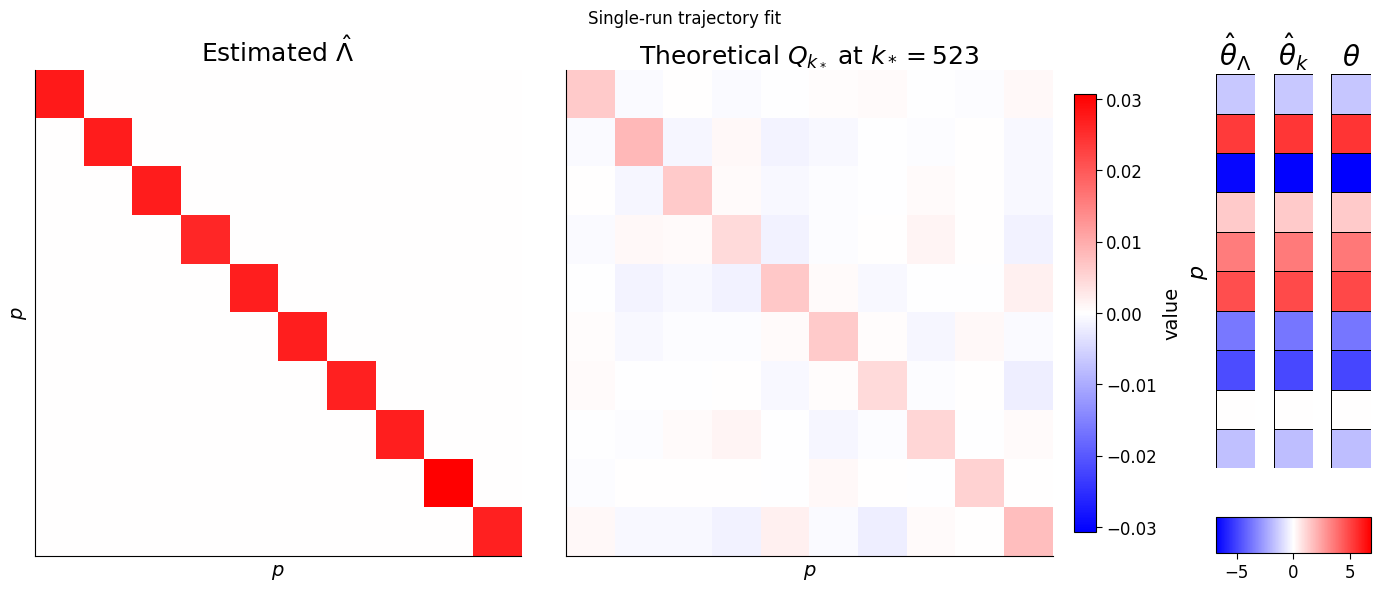

single-run trajectory diagonal distance at callback-selected k* = 523: 3.403221
single-run trajectory matrix distance at callback-selected k* = 523: 3.201725
linear_regression_trajectory_fig3_single_trajectory.pdf


In [4]:
lambda_single = fit_diag_from_trajectory(
    single["theta"],
    single["bias"],
    MAX_EPOCHS+1,
)
Q_single_est = torch.diag(lambda_single)
dist_single_diag = relative_distance(lambda_single, single["lambda_theory_stop"])
dist_single_matrix = matrix_relative_distance(Q_single_est, single["Q_theory_stop"])

fig_single_path = FIG_DIR / "linear_regression_trajectory_fig3_single_trajectory.pdf"
_ = plot_endpoint_comparison(
    Q_est=Q_single_est,
    Q_theory=single["Q_theory_stop"],
    X=X,
    y=single["y"],
    theta_hat=single["model_theta"],
    theta_true=single["beta"],
    out_path=fig_single_path,
    title=f"Single-run trajectory fit",
    theory_panel_title=rf"Theoretical $Q_{{k_*}}$ at $k_*={single_stop_step}$",
)

print(f"single-run trajectory diagonal distance at callback-selected k* = {single_stop_step}: {dist_single_diag:.6f}")
print(f"single-run trajectory matrix distance at callback-selected k* = {single_stop_step}: {dist_single_matrix:.6f}")
print(fig_single_path.name)


## 2) Ten-run stacked endpoint recovery with varying callback stop steps

The 10-run comparison remains an endpoint-only fit across independent runs.

Once the callback picks different stop steps `k_r` across runs, there is no single shared `Q_k` target for the stacked diagonal fit.

For the stacked diagonal estimator, the exact least-squares target is the per-coordinate weighted average

\[
\bar{\lambda}_j
= \frac{\sum_r \theta_{r,j}^2 \, \lambda_j^{(r)}}{\sum_r \theta_{r,j}^2},
\]

where `\lambda^{(r)} = diag(Q_{k_r})` is the theory for run `r` at its own callback-selected stop step.


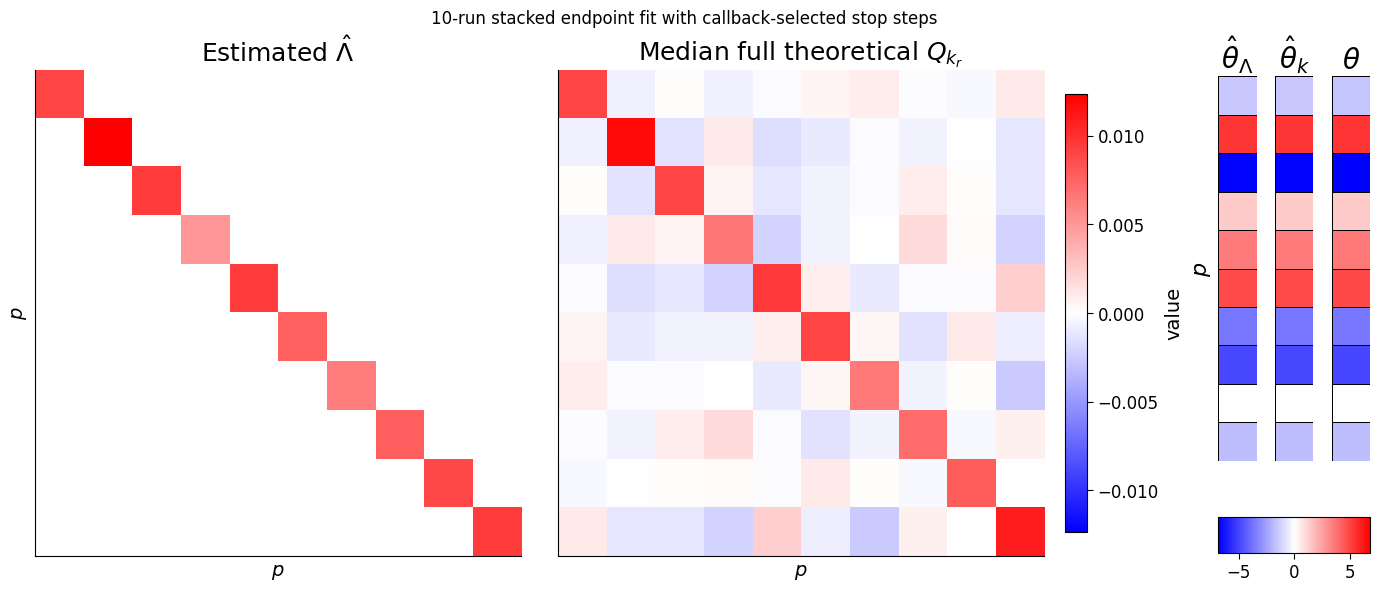

10-run stacked diagonal distance to weighted theory target: 0.129830
10-run stacked matrix distance to median full theory target: 0.342909
linear_regression_trajectory_fig3_10run_endpoint.pdf


In [5]:
theta_endpoints = torch.stack([run["model_theta"] for run in run_data])
update_endpoints = torch.stack(
    [run["update"][run["stop_step"] - 1] for run in run_data]
)
Q_theory_points = torch.stack([run["Q_theory_stop"] for run in run_data])
lambda_theory_points = torch.stack([run["lambda_theory_stop"] for run in run_data])

lambda_runs10 = fit_diag_from_updates(theta_endpoints, update_endpoints)
Q_runs10_est = torch.diag(lambda_runs10)
lambda_theory_runs10 = weighted_theory_diag(theta_endpoints, lambda_theory_points)
Q_theory_runs10_visual = torch.quantile(Q_theory_points, 0.5, dim=0)
dist_runs10_diag = relative_distance(lambda_runs10, lambda_theory_runs10)
dist_runs10_matrix = matrix_relative_distance(Q_runs10_est, Q_theory_runs10_visual)

fig_runs_path = FIG_DIR / "linear_regression_trajectory_fig3_10run_endpoint.pdf"
_ = plot_endpoint_comparison(
    Q_est=Q_runs10_est,
    Q_theory=Q_theory_runs10_visual,
    X=X,
    y=single["y"],
    theta_hat=single["model_theta"],
    theta_true=single["beta"],
    out_path=fig_runs_path,
    title="10-run stacked endpoint fit with callback-selected stop steps",
    theory_panel_title="Median full theoretical $Q_{k_r}$",
)

print(f"10-run stacked diagonal distance to weighted theory target: {dist_runs10_diag:.6f}")
print(f"10-run stacked matrix distance to median full theory target: {dist_runs10_matrix:.6f}")
print(fig_runs_path.name)


## 3) Distance-to-theory curves

Left: for each run, fit the single-trajectory estimator on the whole prefix `1..m`, compare it to that run's own callback-selected diagonal theory target, and then aggregate the resulting curves across 10 runs using the median and IQR.

Right: stack the first `m` callback-stopped endpoints and compare the resulting shared diagonal estimator to the corresponding weighted diagonal theory target.


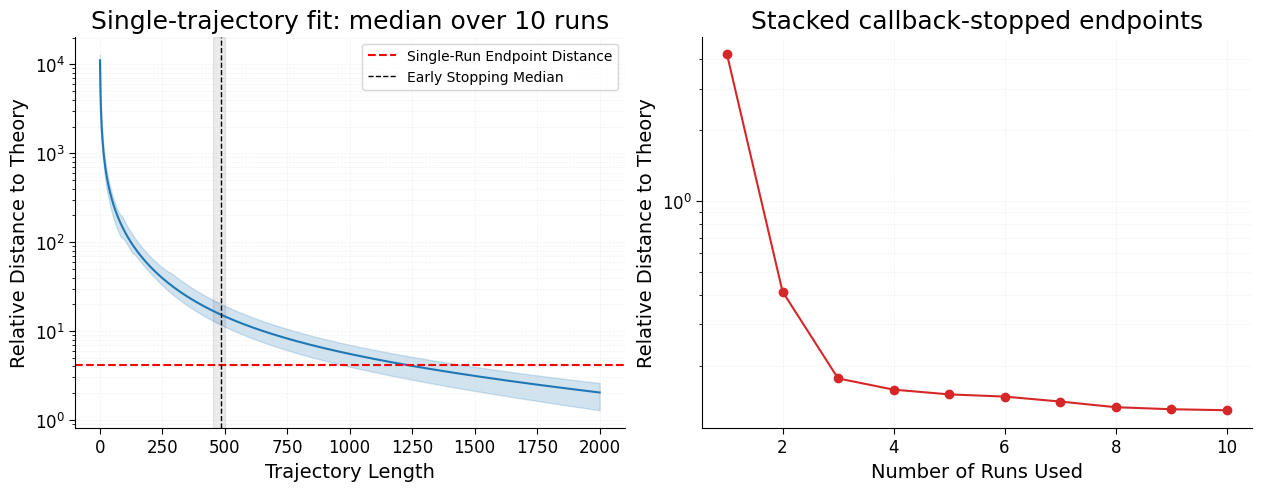

callback stop-step median [IQR]: 485.5 [454.2, 501.0]
median trajectory distance at m=1 [IQR]: 11112.886719 [8244.173828, 12944.708984]
trajectory distance at each run's callback-selected k* [IQR]: 15.253193 [12.985670, 19.170626]
median trajectory distance at final plotted m [IQR]: 2.032479 [1.283569, 2.595150]
stacked distance with 1 run: 4.183342
stacked distance with 10 runs: 0.129830
linear_regression_trajectory_distance_to_theory.pdf


In [6]:
step_counts = torch.arange(1, MAX_EPOCHS + 1)
traj_distances = torch.empty(NUM_RUNS, len(step_counts))
for run_idx, run in enumerate(run_data):
    for i, steps_used in enumerate(step_counts.tolist()):
        lam_m = fit_diag_from_trajectory(run["theta"], run["bias"], i+1)
        traj_distances[run_idx, i] = relative_distance(lam_m, run["lambda_theory_stop"])

traj_distance_median = torch.quantile(traj_distances, 0.5, dim=0)
traj_distance_q1 = torch.quantile(traj_distances, 0.25, dim=0)
traj_distance_q3 = torch.quantile(traj_distances, 0.75, dim=0)
stop_steps_tensor = torch.tensor(stop_steps, dtype=torch.float32)
stop_step_median = torch.quantile(stop_steps_tensor, 0.5).item()
stop_step_q1 = torch.quantile(stop_steps_tensor, 0.25).item()
stop_step_q3 = torch.quantile(stop_steps_tensor, 0.75).item()
stop_distance_values = torch.tensor(
    [traj_distances[idx, run["stop_step"] - 1].item() for idx, run in enumerate(run_data)]
)
stop_distance_median = torch.quantile(stop_distance_values, 0.5).item()
stop_distance_q1 = torch.quantile(stop_distance_values, 0.25).item()
stop_distance_q3 = torch.quantile(stop_distance_values, 0.75).item()

run_counts = torch.arange(1, NUM_RUNS + 1)
run_distances = torch.empty(NUM_RUNS)
for i, m in enumerate(run_counts.tolist()):
    theta_m = theta_endpoints[:m]
    update_m = update_endpoints[:m]
    theory_m = lambda_theory_points[:m]
    q_est_m = fit_diag_from_updates(theta_m, update_m)
    q_theory_m = weighted_theory_diag(theta_m, theory_m)
    run_distances[i] = relative_distance(q_est_m, q_theory_m)

fig_dist_path = FIG_DIR / "linear_regression_trajectory_distance_to_theory.pdf"
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), constrained_layout=True)

axes[0].semilogy(step_counts.numpy(), traj_distance_median.numpy(), color="#1f77b4")
axes[0].fill_between(
    step_counts.numpy(),
    traj_distance_q1.numpy(),
    traj_distance_q3.numpy(),
    color="#1f77b4",
    alpha=0.2,
)
axes[0].axhline(run_distances[0], color='red', linestyle='--', 
                label='Single-Run Endpoint Distance')
axes[0].axvspan(stop_step_q1, stop_step_q3, color="black", alpha=0.08)
axes[0].axvline(stop_step_median, color="black", linestyle="--", linewidth=1,
                label='Early Stopping Median')
axes[0].set_title("Single-trajectory fit: median over 10 runs")
axes[0].set_xlabel("Trajectory Length")
axes[0].set_ylabel("Relative Distance to Theory")
axes[0].grid(alpha=0.3, which="both")
axes[0].legend()

axes[1].semilogy(run_counts.numpy(), run_distances.numpy(), marker="o", color="#d62728")
axes[1].set_title("Stacked callback-stopped endpoints")
axes[1].set_xlabel("Number of Runs Used")
axes[1].set_ylabel("Relative Distance to Theory")
axes[1].grid(alpha=0.3, which="both")

fig.savefig(fig_dist_path, bbox_inches="tight")
display(fig)
plt.close(fig)

print(f"callback stop-step median [IQR]: {stop_step_median:.1f} [{stop_step_q1:.1f}, {stop_step_q3:.1f}]")
print(f"median trajectory distance at m=1 [IQR]: {traj_distance_median[0].item():.6f} [{traj_distance_q1[0].item():.6f}, {traj_distance_q3[0].item():.6f}]")
print(f"trajectory distance at each run's callback-selected k* [IQR]: {stop_distance_median:.6f} [{stop_distance_q1:.6f}, {stop_distance_q3:.6f}]")
print(f"median trajectory distance at final plotted m [IQR]: {traj_distance_median[-1].item():.6f} [{traj_distance_q1[-1].item():.6f}, {traj_distance_q3[-1].item():.6f}]")
print(f"stacked distance with 1 run: {run_distances[0].item():.6f}")
print(f"stacked distance with {NUM_RUNS} runs: {run_distances[-1].item():.6f}")
print(fig_dist_path.name)


In [7]:
print("Generated files:")
print(fig_single_path.name)
print(fig_runs_path.name)
print(fig_dist_path.name)


Generated files:
linear_regression_trajectory_fig3_single_trajectory.pdf
linear_regression_trajectory_fig3_10run_endpoint.pdf
linear_regression_trajectory_distance_to_theory.pdf
